# 第二十九讲：多元线性回归与数值求解

## 目标
同一训练预测背后，参数是否唯一、是否稳定？从四行分数手算出发，对照QR、SVD、lstsq，再看秩亏、单位、近共线和响应扰动。所有数据都是离线合成教学数据；不代表现实预测效果。

本Notebook保留本次执行结果。请在本讲目录中选择新内核并从上到下执行。完整推导见lecture.pdf，实验说明见lab.pdf，18题解答见answers.pdf。

## 设置与完整基线检查
先导入对应脚本，读取三个数据文件。所有配置字段与两份CSV都与正文基线比对；改数据后应另写实验结论，不能沿用原来的数值解释。

In [1]:
from pathlib import Path
import sys, json, math, io
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
root = Path.cwd()
if not (root / "experiment.py").is_file():
    candidates = [root / "units/029", root / "ml-course-production/units/029"]
    root = next((p for p in candidates if (p / "experiment.py").is_file()), root)
if not (root / "experiment.py").is_file():
    raise FileNotFoundError("请从本讲目录打开Notebook")
sys.path.insert(0, str(root))
import experiment as e
from fractions import Fraction
A, y = e.load_hand()
vectors = e.load_vectors()
spec = e.load_spec()
expected = {"kind":"synthetic_multivariate_least_squares_demo", "near_collinear_powers":[0,8,16,24,32,40,48], "noise_scale":0.0625, "response_perturbation":2**-20, "rcond_values":[1e-15,1e-8,0.001], "feature_rescaling":100.0}
e.require(spec == expected, "配置已改变；请另写说明，不沿用基线答案")
e.require(np.array_equal(A, [[1,0,0],[1,1,0],[1,0,1],[1,1,1]]) and np.array_equal(y,[1,3,0,4]), "四行基线已改变")
plt.rcParams.update({"font.family":"DejaVu Sans", "figure.facecolor":"white", "axes.grid":True, "grid.alpha":.2})
def show(fig):
    fig.tight_layout(pad=1.3, w_pad=2.2)
    buffer=io.BytesIO(); fig.savefig(buffer,format="png",dpi=135,bbox_inches="tight")
    display(Image(data=buffer.getvalue())); plt.close(fig)
print({"data_available":True,"A_shape":A.shape,"y_shape":y.shape,"numpy":np.__version__})

{'data_available': True, 'A_shape': (4, 3), 'y_shape': (4,), 'numpy': '2.3.5'}


## 1. 精确手算与三种损失
用Fraction处理原始数据。这里的参照独立于浮点求解器；SSE、MSE、J分别是总和、平均和带1/2的平均。

In [2]:
exact = e.exact_ols(e.stored_fractions(A), [Fraction.from_float(float(v)) for v in y])
e.require(exact["beta"] == ["1/2","3","0"] and exact["sse"] == "1", "手算锚点")
print(json.dumps(exact, ensure_ascii=False, indent=2))

{
  "gram": [
    [
      "4",
      "2",
      "2"
    ],
    [
      "2",
      "2",
      "1"
    ],
    [
      "2",
      "1",
      "2"
    ]
  ],
  "rhs": [
    "8",
    "7",
    "4"
  ],
  "rank": 3,
  "beta": [
    "1/2",
    "3",
    "0"
  ],
  "prediction": [
    "1/2",
    "7/2",
    "1/2",
    "7/2"
  ],
  "residual": [
    "1/2",
    "-1/2",
    "-1/2",
    "1/2"
  ],
  "sse": "1",
  "mse": "1/4",
  "J": "1/8"
}


## 2. 分别比较系数、预测和残差
lstsq、自己组织的SVD、薄QR和正规方程对照使用完全相同的输入。这个良态小例中结果都应接近手算，但不能据此证明所有数值路线在所有问题上同样稳定。

lstsq {'beta': [0.4999999999999999, 2.9999999999999982, -5.98774659582617e-16], 'sse': 0.9999999999999998, 'rank': 3, 'gradient_norm': 1.731222741144367e-15}
svd {'beta': [0.49999999999999994, 2.9999999999999987, -5.531216992196819e-16], 'sse': 0.9999999999999998, 'rank': 3, 'gradient_norm': 1.3507871887578988e-15}
qr {'beta': [0.5000000000000002, 2.9999999999999987, 8.881784197001252e-16], 'sse': 1.0, 'rank': 3, 'gradient_norm': 3.7238012298709097e-16}
normal {'beta': [0.5, 3.0, 0.0], 'sse': 1.0, 'rank': 3, 'gradient_norm': 0.0}


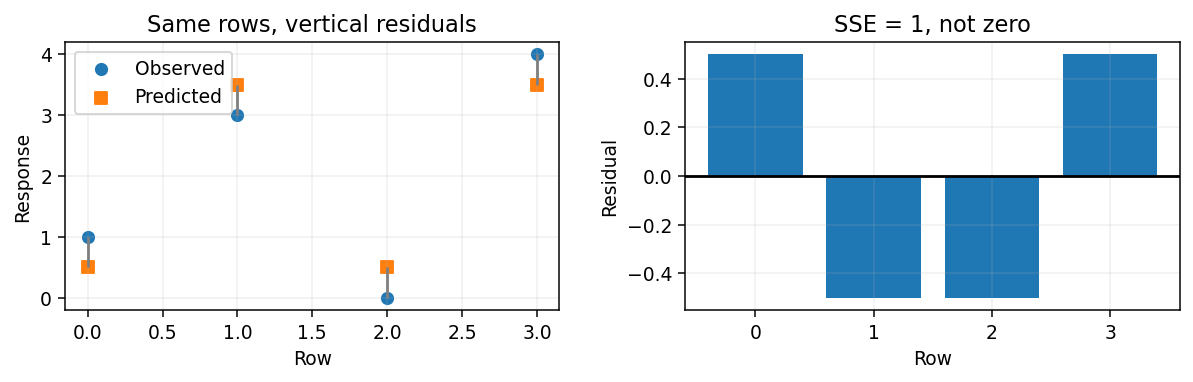

In [3]:
hand = {method:e.solve_ols(A,y,method) for method in ["lstsq","svd","qr","normal"]}
for method, result in hand.items():
    print(method, {key:result[key] for key in ["beta","sse","rank","gradient_norm"]})
fig, axs = plt.subplots(1,2,figsize=(9,3))
idx=np.arange(4); fit=np.array(hand["lstsq"]["prediction"])
axs[0].scatter(idx,y,label="Observed");axs[0].scatter(idx,fit,marker="s",label="Predicted");axs[0].vlines(idx,y,fit,color="gray");axs[0].legend();axs[0].set(title="Same rows, vertical residuals",xlabel="Row",ylabel="Response")
axs[1].bar(idx,y-fit);axs[1].axhline(0,color="black");axs[1].set(title="SSE = 1, not zero",xlabel="Row",ylabel="Residual")
show(fig)

## 3. 形状是正确残差的一部分
广播可以产生一个可计算但语义错误的数组。之后调用规范入口，应明确拒绝(n,1)响应，而不是悄悄扁平化。

In [4]:
correct = y - fit
wrong = y[:, None] - fit
print({"correct_shape":correct.shape, "wrong_shape":wrong.shape})
try:
    e.solve_ols(A,y[:,None])
except ValueError as error:
    print("Expected rejection:", str(error))
else:
    raise AssertionError("应拒绝错误响应形状")

{'correct_shape': (4,), 'wrong_shape': (4, 4)}
Expected rejection: y must have shape (n,)


## 4. 重复列与单位：先看训练预测，再看新点
报告计算包括全部配置的预先验证。三套参数在训练数据上相同，离开x1=x2关系后却可分歧。最小范数只是额外的选解规则。

Equal training predictions: True
Off-relation row: [1, 0, 1] predictions: [1, 2.5, 4]
Rescaled exact beta: ['1', '3/10001', '300/10001']
Empty raw residual field: [] recomputed SSE: 0.04687499999999992


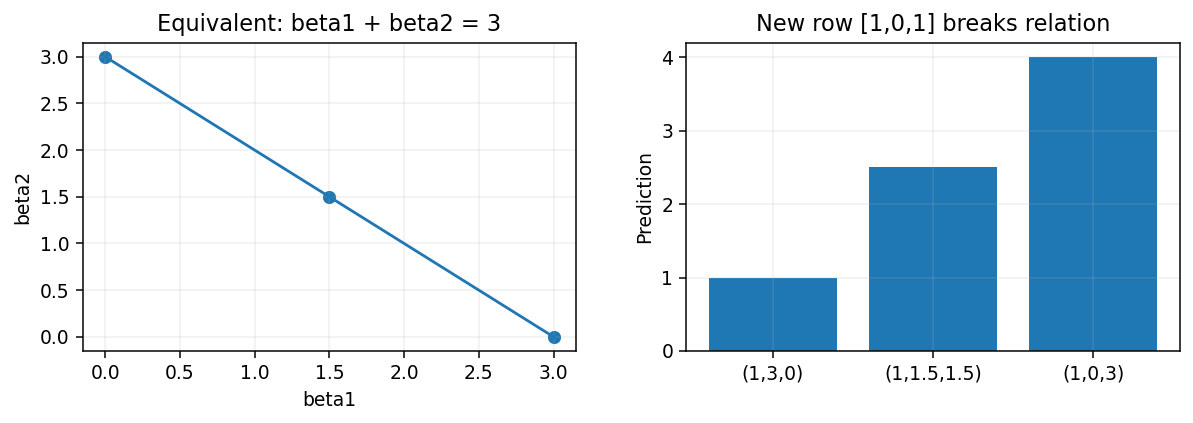

In [5]:
report = e.build_report(A,y,vectors,spec)
print("Equal training predictions:", len(set(tuple(v) for v in report["equivalent_training_predictions"])) == 1)
print("Off-relation row:", report["off_relation_row"], "predictions:", report["off_relation_predictions"])
print("Rescaled exact beta:", report["rescaled_exact_beta"])
print("Empty raw residual field:", report["rank_deficient"]["raw_lstsq_residuals"], "recomputed SSE:", report["rank_deficient"]["sse"])
fig, axs=plt.subplots(1,2,figsize=(9,3.3))
q=np.linspace(0,3,80);axs[0].plot(q,3-q);axs[0].scatter([0,1.5,3],[3,1.5,0]);axs[0].set(xlabel="beta1",ylabel="beta2",title="Equivalent: beta1 + beta2 = 3")
axs[1].bar(["(1,3,0)","(1,1.5,1.5)","(1,0,3)"],report["off_relation_predictions"]);axs[1].set(title="New row [1,0,1] breaks relation",ylabel="Prediction")
show(fig)

## 5. 近共线族的精确存储与独立参照
七个δ都严格为正。每个矩阵与响应先通过逐元素Fraction存储核对，精确秩都是3。有效rank则取决于阈值。参数误差、预测误差和训练SSE需要各自报告。

{'k': 0, 'stored_rank': 3, 'rank': 3, 'condition': 5.487225637230223, 'coefficient_error': 9.155133597044475e-16, 'prediction_error': 5.259223848564703e-15, 'SSE': 0.04687499999999989}
{'k': 8, 'stored_rank': 3, 'rank': 3, 'condition': 1354.6254094774056, 'coefficient_error': 3.8938295064593495e-12, 'prediction_error': 2.2342807379225457e-14, 'SSE': 0.04687500000000017}
{'k': 16, 'stored_rank': 3, 'rank': 3, 'condition': 346783.915850914, 'coefficient_error': 4.810774013213349e-07, 'prediction_error': 1.038125206709043e-11, 'SSE': 0.046874999999999944}
{'k': 24, 'stored_rank': 3, 'rank': 3, 'condition': 88776682.53630118, 'coefficient_error': 0.007958038248085731, 'prediction_error': 6.708125166475732e-10, 'SSE': 0.046875000000000056}
{'k': 32, 'stored_rank': 3, 'rank': 3, 'condition': 22726839146.646187, 'coefficient_error': 1514.582929451456, 'prediction_error': 4.987101355228366e-07, 'SSE': 0.046875000000248905}
{'k': 40, 'stored_rank': 3, 'rank': 3, 'condition': 5818115035201.156, 

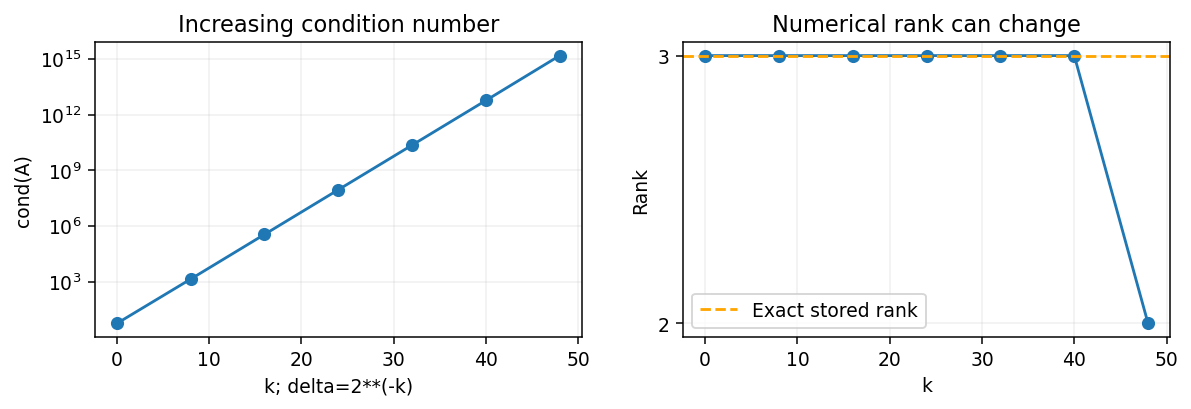

In [6]:
rows=report["near_collinear"]
for row in rows:
    q=row["methods"]["lstsq"]
    e.require(row["stored_exact_rank"] == 3 and row["exact"]["beta"] == ["1","2","1"],"精确参照")
    print({"k":row["power"],"stored_rank":3,"rank":q["rank"],"condition":q["condition_estimate"],"coefficient_error":q["coefficient_error_norm"],"prediction_error":q["reference_prediction_error_norm"],"SSE":q["sse"]})
ks=np.array([r["power"] for r in rows])
fig,axs=plt.subplots(1,2,figsize=(9,3.2))
axs[0].semilogy(ks,[r["methods"]["lstsq"]["condition_estimate"] for r in rows],"o-");axs[0].set(title="Increasing condition number",xlabel="k; delta=2**(-k)",ylabel="cond(A)")
axs[1].plot(ks,[r["methods"]["lstsq"]["rank"] for r in rows],"o-");axs[1].axhline(3,color="orange",ls="--",label="Exact stored rank");axs[1].set(yticks=[2,3],xlabel="k",ylabel="Rank",title="Numerical rank can change");axs[1].legend()
show(fig)

## 6. 求解器误差不做单一排名
正规方程在早期二进制案例恰好精确，后期可能失败；lstsq也可能有巨大系数误差。失败标成缺失状态，绝不填0误差。本图只为对数可视化把真实0放到显示下限，表中保留原始值。

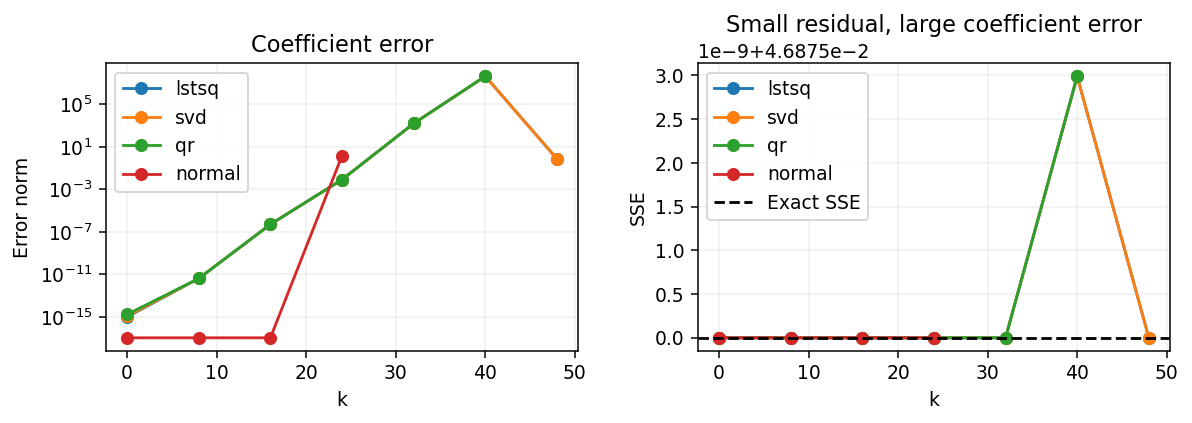

Normal-equation statuses: ['ok', 'ok', 'ok', 'ok', 'linear_algebra_failure', 'linear_algebra_failure', 'linear_algebra_failure']


In [7]:
fig,axs=plt.subplots(1,2,figsize=(9,3.3))
for method in ["lstsq","svd","qr","normal"]:
    coef=[];sse=[]
    for row in rows:
        sol=row["methods"][method]
        coef.append(max(sol["coefficient_error_norm"],1e-17) if sol["status"]=="ok" else np.nan)
        sse.append(sol["sse"] if sol["status"]=="ok" else np.nan)
    axs[0].semilogy(ks,coef,"o-",label=method)
    axs[1].plot(ks,sse,"o-",label=method)
axs[0].set(title="Coefficient error",xlabel="k",ylabel="Error norm");axs[0].legend()
axs[1].axhline(3/64,color="black",ls="--",label="Exact SSE");axs[1].set(title="Small residual, large coefficient error",xlabel="k",ylabel="SSE");axs[1].legend()
show(fig)
print("Normal-equation statuses:",[r["methods"]["normal"]["status"] for r in rows])

## 7. 响应扰动：真实最优参数本来就会变
下面先画精确关系，再看浮点误差。ε固定，系数变化随1/δ增加，训练拟合变化仍为2ε。问题敏感性不等于数值算法错误。

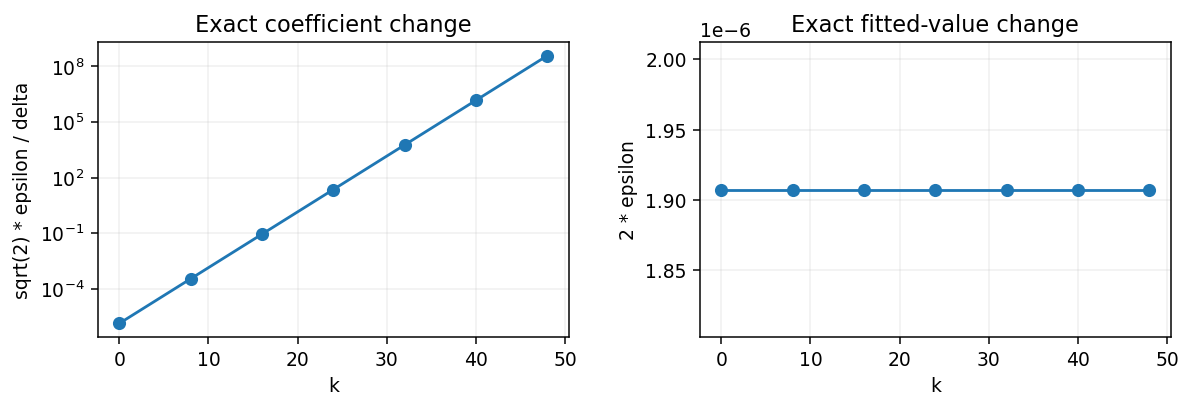

k=48 perturbed exact coefficients: ['1', '-268435454', '268435457']
k=48 computed coefficient error: 379625061.7898994


In [8]:
fig,axs=plt.subplots(1,2,figsize=(9,3.2))
axs[0].semilogy(ks,[r["exact_coefficient_change_norm"] for r in rows],"o-");axs[0].set(title="Exact coefficient change",xlabel="k",ylabel="sqrt(2) * epsilon / delta")
axs[1].plot(ks,[r["exact_prediction_change_norm"] for r in rows],"o-");axs[1].set(title="Exact fitted-value change",xlabel="k",ylabel="2 * epsilon");axs[1].ticklabel_format(axis="y",style="sci",scilimits=(0,0))
show(fig)
print("k=48 perturbed exact coefficients:",rows[-1]["perturbed_exact"]["beta"])
print("k=48 computed coefficient error:",rows[-1]["perturbed_lstsq"]["coefficient_error_norm"])

## 8. rcond扫描与误差含义
同一存储矩阵、同一响应，只改变相对截止线。可能用舍弃一个真实方向换取不同的敏感性与偏差；不能称其为免费恢复精确OLS。

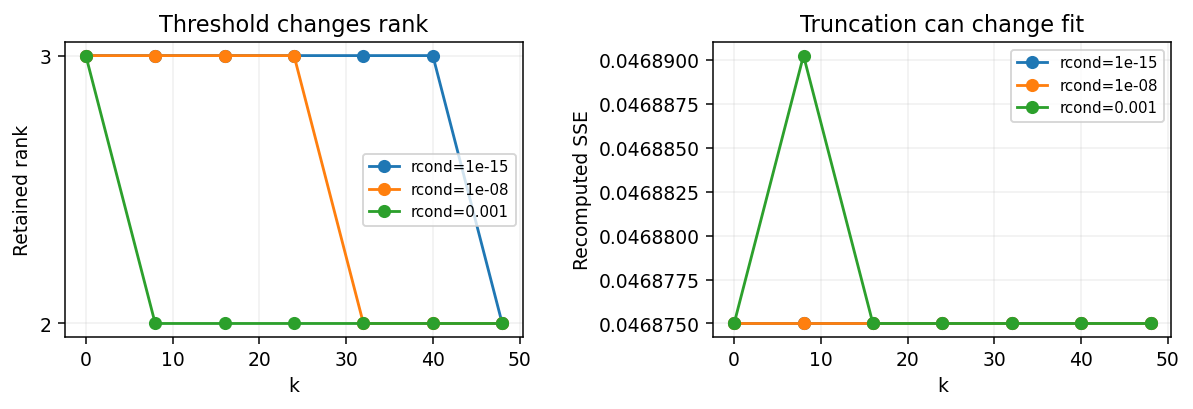

In [9]:
fig,axs=plt.subplots(1,2,figsize=(9,3.2))
for j,rc in enumerate(spec["rcond_values"]):
    axs[0].plot(ks,[r["rcond_sweep"][j]["rank"] for r in rows],"o-",label=f"rcond={rc:g}")
    axs[1].plot(ks,[r["rcond_sweep"][j]["sse"] for r in rows],"o-",label=f"rcond={rc:g}")
axs[0].set(xlabel="k",ylabel="Retained rank",yticks=[2,3],title="Threshold changes rank");axs[0].legend(fontsize=8)
axs[1].set(xlabel="k",ylabel="Recomputed SSE",title="Truncation can change fit");axs[1].legend(fontsize=8)
show(fig)

## 9. 对齐scikit-learn的截距与秩对象
主例的两种路线都比较预测，不把中心化X的rank_和增广A的rank混为同一对象。版本1.8.0的稠密tol观察随报告保留。

In [10]:
print(json.dumps(report["sklearn"],ensure_ascii=False,indent=2))
for key in ["raw_features","augmented"]:
    e.require(np.allclose(report["sklearn"][key]["prediction"],fit,atol=1e-12),"预测对齐")

{
  "version": "1.8.0",
  "raw_features": {
    "beta": [
      0.5,
      3.0,
      -5.551115123125783e-17
    ],
    "prediction": [
      0.5,
      3.5,
      0.49999999999999994,
      3.5
    ],
    "rank_centered_X": 2,
    "singular_centered_X": [
      1.0,
      1.0
    ]
  },
  "augmented": {
    "beta": [
      0.4999999999999999,
      2.9999999999999982,
      -5.98774659582617e-16
    ],
    "prediction": [
      0.4999999999999999,
      3.4999999999999982,
      0.4999999999999993,
      3.499999999999998
    ],
    "rank_A": 3
  },
  "dense_tol_predictions_identical": true
}


## 10. 增加交互项降低训练损失
四行四参数可插值，但没有独立数据用于证明泛化改善。这里展示的是嵌套列空间结论。

{'interaction_beta': [1.0000000000000013, 1.9999999999999971, -1.000000000000002, 2.000000000000004], 'training_sse': 5.374114916818143e-30}


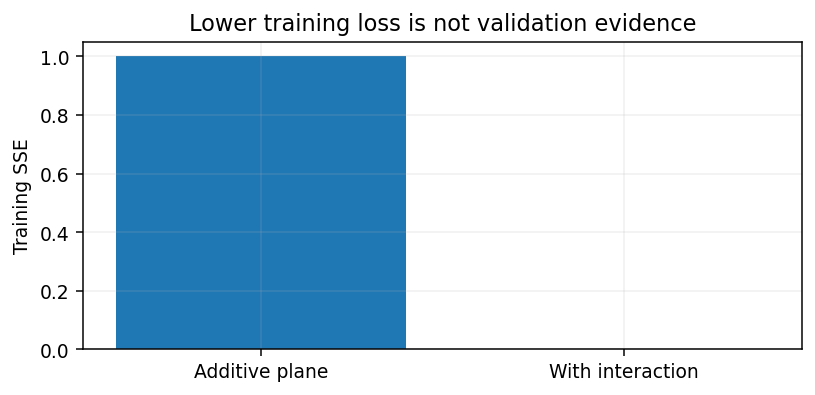

In [11]:
interaction=report["interaction"]
print({"interaction_beta":interaction["beta"],"training_sse":interaction["sse"]})
fig,ax=plt.subplots(figsize=(6.2,3.1));ax.bar(["Additive plane","With interaction"],[hand["lstsq"]["sse"],interaction["sse"]]);ax.set(ylabel="Training SSE",title="Lower training loss is not validation evidence")
show(fig)

## 检查：失败要明确，不伪装成功
构造末尾bool、非有限值、非法rcond与重复JSON键。预期得到可读拒绝。完整坏文件旧输出保护由独立审查测试记录说明；这里不触碰你的现有报告。

In [12]:
bad_cases=[lambda:e.solve_ols([[1,0],[1,True]],[1,2]),lambda:e.solve_ols(A,[1,3,0,float("nan")]),lambda:e.solve_ols(A,y,rcond=1e-200),lambda:e.decimal_token("1e-400"),lambda:e.unique_object([("x",True),("x",1)])]
for i,case in enumerate(bad_cases,1):
    try:case()
    except ValueError as error:print("Expected",i,str(error))
    else:raise AssertionError("坏输入未被拒绝")
print("True zero token allowed:",e.decimal_token("0e-400"))
print(e.self_test())

Expected 1 A row element requires a supported real scalar
Expected 2 y element outside finite supported range
Expected 3 rcond nonfinite or below nonzero floor
Expected 4 JSON nonzero token underflow
Expected 5 duplicate JSON key: x
True zero token allowed: 0.0
{'core_check_groups': 8, 'status': 'passed'}


## 结论与下一步
- 主例β=(1/2,3,0)，SSE=1；残差正交，不代表逐行误差为零。
- 重复列只识别系数总和；最小范数依赖单位，新点离开列关系可产生分歧。
- 七组矩阵实际存储值的精确秩都是3，但默认有效rank最后为2；很小的SSE可以伴随巨大系数误差。
- 固定响应扰动的精确系数变化随1/δ放大，训练预测变化保持2ε；数值计算误差另与精确参照比较。
- 这是有界CPU合成机制实验，不证明现实泛化、因果或大规模速度。继续第30讲时，用解析解作为损失曲面的独立定位参照。

本次在真实新InProcessKernel顺序执行并保留PNG。浏览器Jupyter UI、Anaconda安装和外部socket内核传输未在此环境实测。